In [1]:
# imports 
import numpy as np
import tensorflow as tf
from  tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
# load dataset 
(x_train, y_train),(x_test, y_test)=mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
# normalize pixel 
x_train = x_train/255.0
x_test= x_test/255.0

In [4]:
# reshaper and ad channel
x_train= x_train.reshape(-1,28,28,1)
x_test= x_test.reshape(-1,28,28,1)

In [5]:
model= models.Sequential([
    layers.Conv2D(32,(3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((3,3)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((3,3)),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10, activation='softmax')

])

C:\Users\akank\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
model.fit(x_train , y_train , epochs=3 , batch_size=64)


Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9216 - loss: 0.2684
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9783 - loss: 0.0700
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9842 - loss: 0.0506


In [8]:
predictions= model.predict(x_test)

loss, accuracy= model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9885 - loss: 0.0369


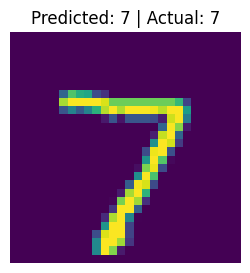

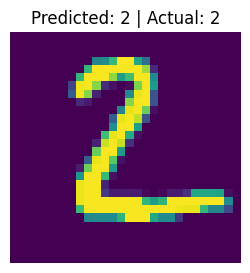

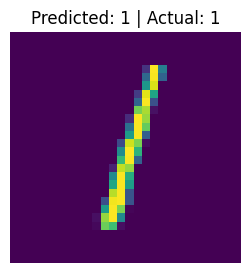

In [10]:
# Show 3 images
for i in range(3):
    plt.figure(figsize=(3,3))
    plt.imshow(x_test[i].reshape(28,28))
    plt.title("Predicted: " + str(np.argmax(predictions[i])) +
              " | Actual: " + str(y_test[i]))
    plt.axis("off")
    plt.show()